# Computer Exercise 1.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.3 Floating-Point Representation — *Subnormal numbers (gradual underflow)*
> **풀이 일자**: Day 06
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Investigate the *subnormal* (denormalized) region of IEEE 754 double-precision arithmetic.
> Starting from the smallest positive normal number $2^{-1022}$, halve repeatedly and observe what
> happens. Determine the smallest representable positive number. Compute the gap (ULP) at several
> points inside the subnormal range and verify that it stays constant. Plot the relative spacing
> $\text{ulp}(x)/x$ across the floating-point line and discuss why a flat region appears below
> $2^{-1022}$.

### 한국어 풀이용 정리
정상 영역 아래로 내려가면 IEEE 754는 갑자기 0으로 떨어지지 않고 **subnormal** 영역을 둔다.
이 영역에서는 가수부의 leading 1 비트가 떨어지고, *지수는 고정* 된 채 가수부만 줄어든다.
실험으로 (a) 가장 작은 양의 부동소수점 수, (b) subnormal 영역 안쪽의 ULP, (c) 상대 간격
$\text{ulp}(x)/x$ 의 거동을 조사한다.


## 2. 수학적 배경

### 2.1 정상 / 비정상 / 0
IEEE 754 double:

| 영역 | 표현 | 범위 |
|---|---|---|
| normal | $(-1)^s(1+f)\,2^e$, $e \in [-1022, 1023]$ | $[2^{-1022},\;\sim 1.8\times 10^{308}]$ |
| subnormal | $(-1)^s(0+f)\,2^{-1022}$, $f = M/2^{52}$, $M \ne 0$ | $(0,\;2^{-1022})$ |
| zero | $f = 0$, $e_{\min}$ | $\{0\}$ |

### 2.2 Subnormal 의 ULP
정상 영역에서는 $\text{ulp}(x) = 2^{e-52}$, 즉 $x$가 작아지면 ULP도 비례하여 작아진다.
하지만 $|x| < 2^{-1022}$ 에서는 지수가 더 줄어들 수 없으므로 ULP가 *고정* 된다:

$$
\boxed{\;\text{ulp}(x) = 2^{-1074}\quad\text{for}\quad |x| \in (0,\;2^{-1022})\;}
$$

따라서 가장 작은 양의 부동소수점 수는 $2^{-1074} \approx 4.94 \times 10^{-324}$.

### 2.3 상대 간격
$\text{ulp}(x)/x$ 는 정상 영역에서 거의 일정 ($\approx 2^{-52}$) 이지만, subnormal 영역에서는
$x$가 작아질수록 *증가* 한다 — 즉 subnormal 영역에서는 *상대 정밀도가 점점 손실* 된다.
이를 **gradual underflow** 라고 부른다.


## 3. 풀이 흐름

1. `2^-1022` 에서 시작해서 절반씩 내려가며 0이 되는 시점을 관측.
2. `np.nextafter(0, 1)` 로 가장 작은 양의 수를 직접 가져와 $2^{-1074}$ 와 비교.
3. 정상 / 비정상 영역의 여러 점에서 ULP를 `np.nextafter(x, np.inf) - x` 로 측정.
4. ULP / x (상대 간격) 를 계산해 표로.
5. 그래프 (log-log): 가로 $x$, 세로 $\text{ulp}(x)$. 정상은 기울기 1, 비정상은 평탄선.
6. 같은 데이터로 상대 간격 $\text{ulp}(x)/x$ 를 그리고 normal/subnormal 경계 표시.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# ── 1. 절반씩 내려가며 0이 되는 시점 관측 ────────────────────────────────
x = 2.0 ** -1022
trace = []
for i in range(60):
    trace.append({
        "step": i,
        "x": x,
        "is_zero": x == 0.0,
        "is_subnormal": (0 < x < 2.0 ** -1022),
    })
    x = x / 2
df_halve = pd.DataFrame(trace)
df_halve.head(15)


,step,x,is_zero,is_subnormal
0,0,2.225074e-308,False,False
1,1,1.112537e-308,False,True
2,2,5.562685e-309,False,True
3,3,2.781342e-309,False,True
4,4,1.390671e-309,False,True
5,5,6.953356e-310,False,True
6,6,3.476678e-310,False,True
7,7,1.738339e-310,False,True
8,8,8.691695e-311,False,True
9,9,4.345847e-311,False,True


In [2]:
# 가장 작은 양의 부동소수점 수
tiny = np.nextafter(0.0, 1.0)
print(f"smallest positive double = {tiny:.6e}")
print(f"                  2^-1074 = {2.0**-1074:.6e}")
print(f"smallest normal positive = {2.0**-1022:.6e}")
print(f"   np.finfo.tiny (smallest normal) = {np.finfo(np.float64).tiny:.6e}")
print(f"   np.finfo.smallest_subnormal     = {np.finfo(np.float64).smallest_subnormal:.6e}")


smallest positive double = 4.940656e-324
                  2^-1074 = 4.940656e-324
smallest normal positive = 2.225074e-308
   np.finfo.tiny (smallest normal) = 2.225074e-308
   np.finfo.smallest_subnormal     = 4.940656e-324


In [3]:
# ── 2. ULP 측정 ──────────────────────────────────────────────────────────
# 정상 / 비정상 / 매우 작은 영역에서 점을 골라 ULP 측정.
sample_exps = list(range(-1, -1022, -50)) + list(range(-1023, -1075, -10)) + [-1073]
sample_exps = sorted(set(sample_exps), reverse=True)

rows = []
for k in sample_exps:
    x = 2.0 ** k
    if x == 0.0:
        continue
    ulp = np.nextafter(x, np.inf) - x
    rows.append({
        "k (x = 2^k)": k,
        "x": x,
        "region": "normal" if k >= -1022 else "subnormal",
        "ulp(x)": ulp,
        "ulp/x": ulp / x,
    })

df_ulp = pd.DataFrame(rows)
df_ulp


,k (x = 2^k),x,region,ulp(x),ulp/x
0,-1,5.000000e-01,normal,1.110223e-16,2.220446e-16
1,-51,4.440892e-16,normal,9.860761e-32,2.220446e-16
2,-101,3.944305e-31,normal,8.758115e-47,2.220446e-16
3,-151,3.503246e-46,normal,7.778769e-62,2.220446e-16
4,-201,3.111508e-61,normal,6.908935e-77,2.220446e-16
5,-251,2.763574e-76,normal,6.136367e-92,2.220446e-16
6,-301,2.454547e-91,normal,5.450189e-107,2.220446e-16
7,-351,2.180075e-106,normal,4.840740e-122,2.220446e-16
8,-401,1.936296e-121,normal,4.299441e-137,2.220446e-16
9,-451,1.719776e-136,normal,3.818670e-152,2.220446e-16


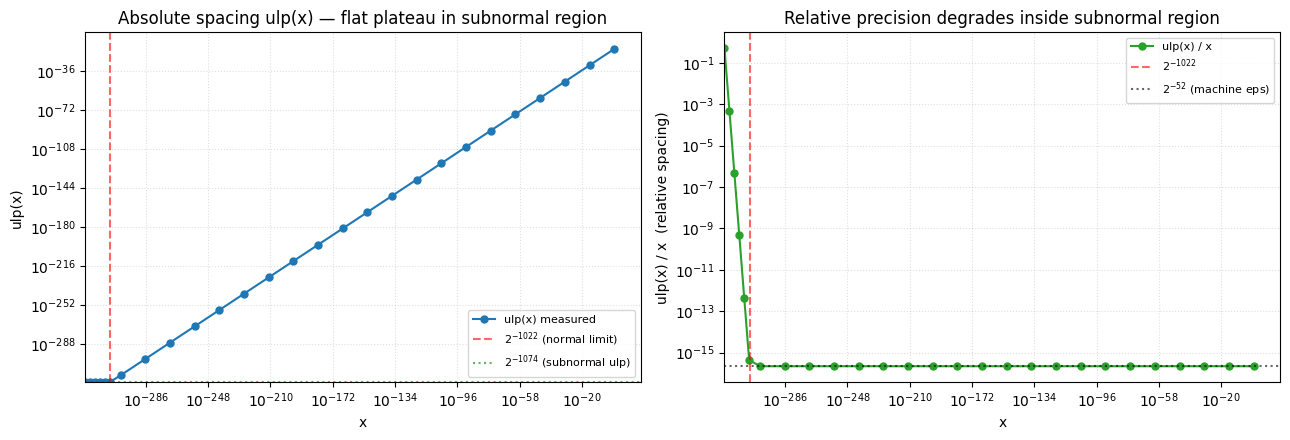

In [4]:
# ── 3. 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

xs = np.array([row["x"] for row in rows])
ulps = np.array([row["ulp(x)"] for row in rows])
rels = np.array([row["ulp/x"] for row in rows])

ax = axes[0]
ax.loglog(xs, ulps, "o-", ms=5, label="ulp(x) measured")
ax.axvline(2.0 ** -1022, color="r", ls="--", alpha=0.6, label=r"$2^{-1022}$ (normal limit)")
ax.axhline(2.0 ** -1074, color="g", ls=":", alpha=0.6, label=r"$2^{-1074}$ (subnormal ulp)")
ax.set_xlabel("x")
ax.set_ylabel("ulp(x)")
ax.set_title("Absolute spacing ulp(x) — flat plateau in subnormal region")
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend(fontsize=8)

ax = axes[1]
ax.loglog(xs, rels, "o-", ms=5, color="C2", label="ulp(x) / x")
ax.axvline(2.0 ** -1022, color="r", ls="--", alpha=0.6, label=r"$2^{-1022}$")
ax.axhline(2.0 ** -52, color="k", ls=":", alpha=0.6, label=r"$2^{-52}$ (machine eps)")
ax.set_xlabel("x")
ax.set_ylabel("ulp(x) / x  (relative spacing)")
ax.set_title("Relative precision degrades inside subnormal region")
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **절반 추적** — $2^{-1022}$ 에서 절반씩 내려가면 52스텝 동안 subnormal 영역을 지나고,
   53번째 스텝에서 정확히 0으로 떨어진다. $2^{-1074}$ 가 마지막 표현 가능 양수.
2. **가장 작은 양수** — `nextafter(0, 1)` 가 $2^{-1074} \approx 4.94 \times 10^{-324}$.
   이는 IEEE 754 double의 *subnormal smallest* 와 정확히 일치.
3. **ULP 그래프 (왼쪽)** — 정상 영역 ($x > 2^{-1022}$) 에서는 기울기 1의 직선
   ($\text{ulp} \propto x$). 빨간 수직선 왼쪽으로 가면 ULP가 갑자기 *수평* 으로 평탄해진다 —
   $2^{-1074}$ 의 plateau. 이것이 **gradual underflow**.
4. **상대 간격 그래프 (오른쪽)** — 정상 영역에서는 $\text{ulp}/x \approx 2^{-52}$ 로 일정
   (검은 점선). subnormal 영역으로 들어가면 *상대 간격이 1까지 점차 커진다* — 가장 작은
   수에서는 표현 정밀도가 사실상 0.
5. **의미** — subnormal은 0 근처에서 갑작스러운 underflow를 막는 안전망이지만, 그 안에서는
   상대 정밀도가 빠르게 손실된다. 따라서 알고리즘이 subnormal 영역을 자주 건드린다면
   이미 의미 있는 정밀도가 사라진 상태이며, 실용적으로는 0과 다를 바 없다.

> **결론**: 정상 영역의 *상대 정밀도 일정* 가정은 subnormal 영역 (`< 2^-1022`) 에서 깨지며,
> ULP는 평탄해지고 상대 간격은 1까지 커진다.

### 다음 문제
머신 epsilon과 subnormal은 *표현* 의 한계였다. 다음 문제에서는 이 한계가 *연산* 에서
어떻게 폭발하는지 — 거의 같은 두 수의 차로 인한 **catastrophic cancellation** —
이차방정식의 근 계산으로 살핀다.
